# 生成伪实验数据

包含：$I(t)$，$Q(t)$。其中每个样本取200个时间点，训练用50000个样本，测试用10000个样本。

### 1. 物理模型概述

我们使用一个 **两模线性模型** 来描述超导量子比特的色散读出结构：

- **模式 a**：Purcell 滤波器，负责将读出信号耦合到传输线，同时抑制量子比特的辐射损耗  
- **模式 b**：读出谐振腔，与量子比特色散耦合

两个模式通过耦合常数 $J$ 相互作用。量子比特本身 **不作为动力学自由度显式模拟**，而是在色散极限下，通过对读出腔频率的位移来体现其状态：

- 量子比特处于 $|g⟩$：  $ \omega_b \rightarrow \omega_b - \chi $
- 量子比特处于 $|e⟩$：  $ \omega_b \rightarrow \omega_b + \chi $

所有动力学都在驱动频率 $\omega_d$ 的旋转坐标系中进行，因此模拟的量是 **复包络（baseband）**，而不是 GHz 量级的真实 RF 信号。

定义：

- 失谐：$\Delta_a = \omega_a - \omega_d$，$\Delta_b = \omega_b - \omega_d$，$\Delta_{b,s} = \Delta_b + s\chi$，其中 $s=-1$ 表示 $|g⟩$，$s=+1$ 表示 $|e⟩$
- 耗散：外耦合速率 $\kappa_a,\ \kappa_b$，内损耗速率 $\gamma_a,\ \gamma_b$，总半线宽 $\Gamma_a = (\kappa_a + \gamma_a)/2,\ \Gamma_b = (\kappa_b + \gamma_b)/2$

在旋转系中，两模的平均场演化方程为：

\begin{aligned}
\frac{da}{dt} &= -(\Gamma_a + i\Delta_a)\,a - iJ b + \sqrt{\kappa_a}\,a_{\text{in}}(t) \\
\frac{db}{dt} &= -(\Gamma_b + i\Delta_{b,s})\,b - iJ a
\end{aligned}

在当前数据生成器中，假设驱动仅从 Purcell 滤波器侧注入，因此 $b_{\text{in}}(t)=0$。

### 2. 输入–输出关系

根据输入–输出理论，可得到端口处的输出场：

- **Purcell 端口（反射型读出）**：$ a_{\text{out}}(t) = a_{\text{in}}(t) - \sqrt{\kappa_a}\,a(t) $

- **读出腔端口**：$ b_{\text{out}}(t) = -\sqrt{\kappa_b}\,b(t) $

生成脚本中可以通过参数 `measure="a_out"（默认）` 或 `"b_out"` 来选择观测哪一路信号。

### 3. IQ 信号与 RF 信号的关系

本模型直接输出 **IQ 基带信号** $s(t)$，它等价于理想 IQ 解调后的结果：$ I(t) = \Re[s(t)], \ Q(t) = \Im[s(t)] $

如果要写出对应的真实 RF 电压信号，其形式为：$ V_{\text{RF}}(t) \propto \Re\left\{ s(t)\,e^{-i\omega_d t} \right\} $

### 4. 数字滤波

实验中通常不会直接用完整的时间序列做判决，而是对某个时间窗内的 IQ 信号做积分或加权：$z = \int w(t)\,[I(t) + iQ(t)]\,dt$

常见选择包括：**1. Boxcar 积分**：$ w(t)=\text{const} $，在读出脉冲平顶区间内平均。**2. 匹配滤波（matched filter）**：$ w(t) \propto \langle s_e(t) - s_g(t) \rangle $。

### 5. IQ 不平衡与振荡的来源

实验中常见的一个现象是 IQ 波形中叠加周期性振荡（例如 ~50 MHz），这通常来自 **IQ 不平衡或镜像频率泄露**。

在基带中，一个常用的模型是：$s_{\text{meas}}(t) = s(t) + \varepsilon\,e^{i2\omega_{\text{IF}}t}\,s^*(t)$

其中：IQ 不平衡强度 $\varepsilon$，产生拍频的角频率 $2\omega_{\text{IF}}$。生成器中通过 `iq_imbalance` 与 `beat_freq_MHz` 参数来控制该效应。

### 6. 噪声模型
为了更贴近真实实验，数据生成器包含三类常见噪声：
1. **放大器白噪声 `amp_noise_std`**：每个采样点独立加入，模拟 HEMT/JPA 等放大链路噪声
2. **相位噪声 `phase_noise_std`**：每条读出波形整体乘以随机相位 $e^{i\phi}$，对应本振（LO）相位抖动、触发抖动等
3. **慢频漂 `slow_detune_std`**：每个 shot 的共振频率随机漂移，用于模拟低频噪声、1/f 噪声或实验环境漂移

### 7. 数据集格式（`.npz`）

生成的数据集面向机器学习与数值分析，**不包含显式时间轴**。
保存内容包括：
- `X_train`：形状 `(n_train, n_points, 2)`，`float32`；最后一维为 `[I, Q]`
- `y_train`：形状 `(n_train,)`，`int64`；标签：`0 = |g⟩`，`1 = |e⟩`
- `X_test`, `y_test`：与训练集格式相同
- `params_json`：JSON 字符串，记录生成该数据集时使用的所有参数


In [136]:
!python -m scripts.gen_data_readout --out data/test_readout.npz --n_points 200 --n_train 20000 --n_test 2000 --amp_noise_std 0.1 --phase_noise_std 0.05

Saved data/test_readout.npz
train: (20000, 200, 2) test: (2000, 200, 2)


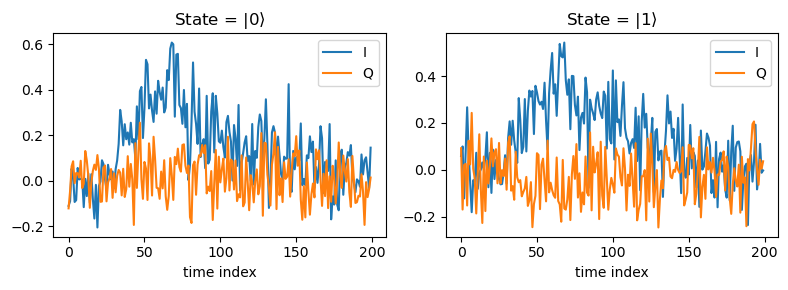

In [137]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("data/test_readout.npz", allow_pickle=True)
Xtr, y_train, Xte, y_test = d["X_train"], d["y_train"], d["X_test"], d["y_test"]
X_train = np.mean(Xtr, axis=1)
X_test = np.mean(Xte, axis=1)

rng = np.random.default_rng()
idx0 = rng.choice(np.where(y_train == 0)[0])
idx1 = rng.choice(np.where(y_train == 1)[0])

x0, x1 = Xtr[idx0,:,:], Xtr[idx1,:,:]

titles = [fr"State = $|0\rangle$", fr"State = $|1\rangle$"]

t = np.arange(x0.shape[0])

plt.figure(figsize=(8,3))

for (i, x) in zip([0,1], [x0,x1]):
    plt.subplot(1,2,i+1)
    plt.plot(t, x[:,0], label='I')
    plt.plot(t, x[:,1], label='Q')
    plt.title(titles[i])
    plt.xlabel('time index')
    plt.legend()

plt.tight_layout()
plt.show()

# 实验数据

In [1]:
import os
import numpy as np 
from src.readout import * 

dir = "data/readout_data"
x, y = load_experiment_data(dir)

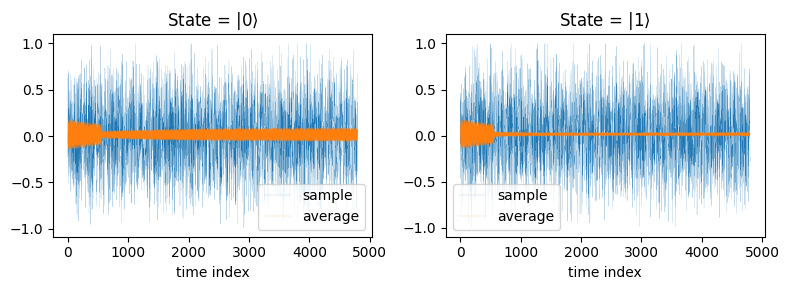

In [2]:
import matplotlib.pyplot as plt

rng = np.random.default_rng()
idx = [rng.choice(np.where(y == 0)[0]),
       rng.choice(np.where(y == 1)[0])]

titles = [fr"State = $|0\rangle$", fr"State = $|1\rangle$"]

t = np.arange(x.shape[1])

plt.figure(figsize=(8,3))

for i in [0,1]:
    plt.subplot(1,2,i+1)
    plt.plot(t, x[idx[i],:], label="sample", lw=0.1)
    # plt.plot(t, x[idx[i],:] * np.cos(2*np.pi*f_demod*t), label="I(t)")
    # plt.plot(t, x[idx[i],:] * np.sin(2*np.pi*f_demod*t), label="Q(t)")
    plt.plot(t, np.mean(x[np.where(y==i)[0],:], axis=0), label="average", lw=0.1)
    plt.title(titles[i])
    plt.xlabel('time index')
    plt.legend()
    # plt.xlim((1000, 1500))

plt.tight_layout()
plt.show()

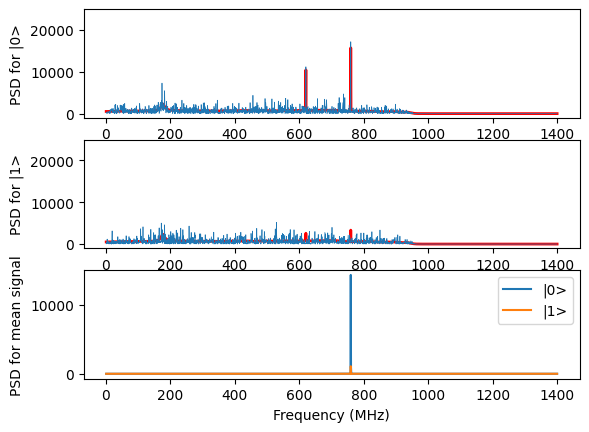

In [74]:
import matplotlib.pyplot as plt
from src.readout import compute_psd_rfft

fs =2.8e9
window = (1000, -1)
freq, psd = compute_psd_rfft(x, fs, window=window)

psd0 = np.mean(psd[y==0,:], axis=0)
psd1 = np.mean(psd[y==1,:], axis=0)
_, psd0_mean = compute_psd_rfft(np.mean(x[y==0,:],axis=0), fs, window=window)
_, psd1_mean = compute_psd_rfft(np.mean(x[y==1,:],axis=0), fs, window=window)

mask = (freq > 0e6) & (freq <= 1.5e9)

plt.figure()
plt.subplot(3,1,1)
plt.plot(freq[mask]/1e6, psd0[mask], lw=2, c='r')
plt.plot(freq[mask]/1e6, psd[idx[0],mask], lw=0.5)
plt.ylabel("PSD for |0>")
plt.ylim((-1e3,2.5e4))
plt.subplot(3,1,2)
plt.plot(freq[mask]/1e6, psd1[mask], lw=2, c='r')
plt.plot(freq[mask]/1e6, psd[idx[1],mask], lw=0.5)
plt.ylabel("PSD for |1>")
plt.ylim((-1e3,2.5e4))
plt.subplot(3,1,3)
plt.plot(freq[mask]/1e6, psd0_mean[0,mask], label="|0>")
plt.plot(freq[mask]/1e6, psd1_mean[0,mask], label="|1>")
plt.xlabel("Frequency (MHz)")
plt.ylabel("PSD for mean signal")
plt.legend()
# plt.title(f"Peak = {f_peak/1e6:.3f} MHz")
plt.show()


In [45]:
from src.readout import peak_snr_and_width_from_psd

import pandas as pd

r0 = peak_snr_and_width_from_psd(freq, psd0, prominence_db=3, noise_med_window_bins=201)
display(pd.DataFrame(r0))

r1 = peak_snr_and_width_from_psd(freq, psd1, prominence_db=3, noise_med_window_bins=201)
display(pd.DataFrame(r1))



,peak_idx,f0_hz,snr_db,fwhm_hz,peak_psd_db,noise_floor_db
0,240,1.768421e+08,4.827441,1.794255e+07,33.555688,28.728247
1,842,6.204211e+08,11.389689,1.305202e+06,40.202170,28.812481
2,1031,7.596842e+08,14.141659,9.600194e+05,41.969104,27.827445


,peak_idx,f0_hz,snr_db,fwhm_hz,peak_psd_db,noise_floor_db
0,240,1.768421e+08,4.950454,1.800936e+07,33.672293,28.721840
1,842,6.204211e+08,5.289623,1.076561e+06,34.146275,28.856652
2,1031,7.596842e+08,7.330762,9.169382e+05,35.237465,27.906703


In [76]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

def band_power_from_rfft(x, fs, f0_hz, fwhm_hz=1e6):
    """
    x: (n_shots, T), real
    return: per-shot band-averaged power around f0 (linear)
    """
    Xf = np.fft.rfft(x, axis=1)
    freq = np.fft.rfftfreq(x.shape[1], d=1/fs)
    P = np.abs(Xf) ** 2

    df = freq[1] - freq[0]
    half_bins = max(1, int(round((fwhm_hz / 2) / df)))  # small broadening, at least 1 bin

    i0 = int(np.argmin(np.abs(freq - f0_hz)))
    l = max(0, i0 - half_bins)
    r = min(len(freq), i0 + half_bins + 1)

    return P[:, l:r].mean(axis=1), freq[l:r]

# --- 1) broaden to FWHM = 1 MHz
p620, band620 = band_power_from_rfft(x[:,1000:], fs, 620e6, fwhm_hz=1e6)
p760, band760 = band_power_from_rfft(x[:,1000:], fs, 760e6, fwhm_hz=1e6)

print("620 band [MHz]:", band620[0]/1e6, "to", band620[-1]/1e6)
print("760 band [MHz]:", band760[0]/1e6, "to", band760[-1]/1e6)

# --- 2) split by y==0/1 and compute correlations
for cls in [0, 1]:
    m = (y == cls)
    r_p, p_p = pearsonr(p620[m], p760[m])
    r_s, p_s = spearmanr(p620[m], p760[m])
    print(f"class {cls}: Pearson={r_p:.4f} (p={p_p:.2e}), Spearman={r_s:.4f} (p={p_s:.2e}), n={m.sum()}")


620 band [MHz]: 618.9473684210526 to 620.421052631579
760 band [MHz]: 758.9473684210526 to 760.421052631579
class 0: Pearson=0.6716 (p=0.00e+00), Spearman=0.5796 (p=0.00e+00), n=10000
class 1: Pearson=0.8922 (p=0.00e+00), Spearman=0.6213 (p=0.00e+00), n=10000


(0.0, 20000.0)

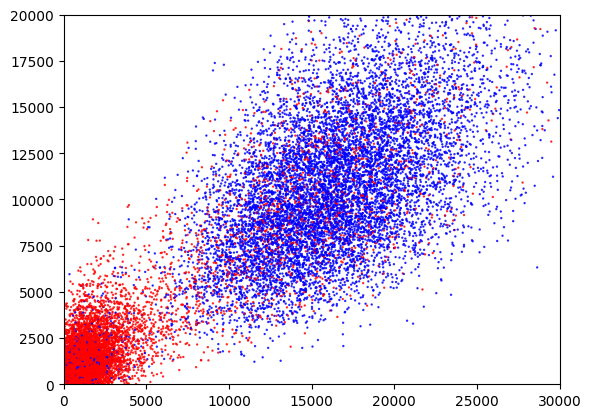

In [98]:
idx = rng.permutation(np.arange(len(y)))
plt.scatter( psd[idx,1031], psd[idx,842], c=y[idx], alpha=0.8, s=0.5, cmap='bwr')
# plt.xscale('log')
# plt.yscale('log')
plt.xlim((0, 3e4))
plt.ylim((0, 2e4))

In [143]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score, accuracy_score, confusion_matrix

def learn_single_filter(X, y, reg=1e-3):
    X0, X1 = X[y==0], X[y==1]
    mu0, mu1 = X0.mean(0), X1.mean(0)
    C0 = np.cov(X0, rowvar=False)
    C1 = np.cov(X1, rowvar=False)
    Sw = 0.5 * (C0 + C1)
    f = np.linalg.solve(Sw + reg*np.eye(Sw.shape[0]), (mu1 - mu0))
    return f

def learn_two_filters(X, y, reg=1e-3):
    X0, X1 = X[y==0], X[y==1]
    mu0, mu1 = X0.mean(0), X1.mean(0)
    C0 = np.cov(X0, rowvar=False)
    C1 = np.cov(X1, rowvar=False)
    Sw = 0.5 * (C0 + C1)
    A = Sw + reg*np.eye(Sw.shape[0])
    f0 = np.linalg.solve(A, mu0)
    f1 = np.linalg.solve(A, mu1)
    return f0, f1

def best_threshold(scores, y):
    s0, s1 = scores[y==0], scores[y==1]
    cand = np.sort(np.unique(np.r_[s0, s1]))
    thr = np.r_[cand[0]-1e-12, (cand[:-1]+cand[1:])/2, cand[-1]+1e-12]

    best = (-1, None, None)  # bacc, t, direction
    for t in thr:
        # predict 1 if s >= t
        F0 = (s0 < t).mean(); F1 = (s1 >= t).mean(); b = 0.5*(F0+F1)
        if b > best[0]: best = (b, t, "ge")
        # predict 1 if s <= t
        F0 = (s0 > t).mean(); F1 = (s1 <= t).mean(); b = 0.5*(F0+F1)
        if b > best[0]: best = (b, t, "le")
    return best

def predict_by_threshold(scores, t, direction):
    if direction == "ge":
        return (scores >= t).astype(int)
    return (scores <= t).astype(int)

def eval_metrics(y_true, y_pred):
    bacc = balanced_accuracy_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    F00 = cm[0,0] / cm[0].sum()
    F11 = cm[1,1] / cm[1].sum()
    return {"balanced_acc": bacc, "acc": acc, "F00": F00, "F11": F11, "cm": cm}

# X: (n_shots, T) time-domain traces (or chosen feature vector per shot)
# y: (n_shots,) labels 0/1
Xtr, Xte, ytr, yte = train_test_split(x[:,1000:3000:], y, test_size=0.2, random_state=42, stratify=y)

# -------- Scheme A: single filter + threshold --------
f = learn_single_filter(Xtr, ytr, reg=1e-3)
Str = Xtr @ f
Ste = Xte @ f
_, t, direction = best_threshold(Str, ytr)
yp_single = predict_by_threshold(Ste, t, direction)
m_single = eval_metrics(yte, yp_single)

# -------- Scheme B: double filter + LDA on [S0,S1] --------
f0, f1 = learn_two_filters(Xtr, ytr, reg=1e-3)
Ztr = np.c_[Xtr @ f0, Xtr @ f1]
Zte = np.c_[Xte @ f0, Xte @ f1]

lda = LinearDiscriminantAnalysis()
lda.fit(Ztr, ytr)
yp_double = lda.predict(Zte)
m_double = eval_metrics(yte, yp_double)

print("Single filter + threshold:", m_single)
print("Double filter + LDA      :", m_double)




Single filter + threshold: {'balanced_acc': 0.8912500000000001, 'acc': 0.89125, 'F00': np.float64(0.923), 'F11': np.float64(0.8595), 'cm': array([[1846,  154],
       [ 281, 1719]])}
Double filter + LDA      : {'balanced_acc': 0.8915, 'acc': 0.8915, 'F00': np.float64(0.921), 'F11': np.float64(0.862), 'cm': array([[1842,  158],
       [ 276, 1724]])}


In [144]:
(m_single["F00"], m_single["F11"]), (m_double["F00"], m_double["F11"])

((np.float64(0.923), np.float64(0.8595)),
 (np.float64(0.921), np.float64(0.862)))

In [216]:
import numpy as np
from scipy.optimize import minimize

def train_full_filter(
    X, y,
    l2=1e-4,
    smooth=1e-2,
    maxiter=400,
    objective="logistic",   # "logistic" | "hinge" | "fisher"
    class_weight=None       # None or dict {0:w0, 1:w1}
):
    """
    Learn full-length filter f (each point trainable) and bias b.
    X: (n_shots, T), y in {0,1}
    """
    X = np.asarray(X, float)
    y = np.asarray(y).astype(int)
    n, T = X.shape
    yy = 2*y - 1  # {-1,+1}

    # weights
    if class_weight is None:
        w = np.ones(n, dtype=float)
    else:
        w0 = float(class_weight.get(0, 1.0))
        w1 = float(class_weight.get(1, 1.0))
        w = np.where(y == 0, w0, w1).astype(float)
    w /= (w.mean() + 1e-12)

    # smoothness matrix D^T D
    if T >= 3:
        D = np.zeros((T-2, T))
        for i in range(T-2):
            D[i, i:i+3] = [1.0, -2.0, 1.0]
    else:
        D = np.zeros((1, T))
    DtD = D.T @ D

    def unpack(theta):
        return theta[:T], theta[T]

    # Closed-form Fisher-like solution
    if objective == "fisher":
        X0, X1 = X[y == 0], X[y == 1]
        mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)
        C0 = np.cov(X0, rowvar=False)
        C1 = np.cov(X1, rowvar=False)
        Sw = 0.5 * (C0 + C1)
        A = Sw + l2*np.eye(T) + smooth*DtD
        f = np.linalg.solve(A, (mu1 - mu0))
        b = -0.5 * (mu0 + mu1) @ f
        return {"f": f, "b": float(b), "objective": "fisher", "opt": None}

    def loss_grad(theta):
        f, b = unpack(theta)
        margin = yy * (X @ f + b)

        if objective == "logistic":
            # sum w_i * log(1 + exp(-m_i))
            loss_vec = np.logaddexp(0.0, -margin)
            loss = np.mean(w * loss_vec)
            p = 1.0 / (1.0 + np.exp(margin))            # sigmoid(-margin)
            coeff = -(w * yy * p) / n
        elif objective == "hinge":
            # squared hinge: max(0, 1 - m)^2
            z = 1.0 - margin
            active = z > 0
            loss = np.mean(w * (z * active)**2)
            coeff = np.zeros_like(margin)
            coeff[active] = -(2.0 * w[active] * z[active] * yy[active]) / n
        else:
            raise ValueError("objective must be 'logistic', 'hinge', or 'fisher'")

        gf = X.T @ coeff
        gb = np.sum(coeff)

        # regularization
        loss += l2 * (f @ f) + smooth * (f @ DtD @ f)
        gf += 2.0*l2*f + 2.0*smooth*(DtD @ f)

        grad = np.concatenate([gf, [gb]])
        return float(loss), grad

    theta0 = np.zeros(T + 1, dtype=float)
    res = minimize(
        fun=lambda th: loss_grad(th)[0],
        x0=theta0,
        jac=lambda th: loss_grad(th)[1],
        method="L-BFGS-B",
        options={"maxiter": int(maxiter)}
    )
    f, b = unpack(res.x)
    return {"f": f, "b": float(b), "objective": objective, "opt": res}


def predict_full_filter(X, model):
    s = np.asarray(X, float) @ model["f"] + model["b"]
    yhat = (s >= 0).astype(int)
    return s, yhat


In [220]:
# usage
Xtr, Xte, ytr, yte = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

m_log = train_full_filter(Xtr, ytr, objective="logistic", l2=1e-4, smooth=1e-3)
m_hin = train_full_filter(Xtr, ytr, objective="hinge",    l2=1e-4, smooth=1e-3)
m_fis = train_full_filter(Xtr, ytr, objective="fisher",   l2=1e-4, smooth=1e-3)

for model in [m_log, m_hin, m_fis]:
    s_te, yhat_te = predict_full_filter(Xte, model)
    print(f"test balanced acc ({model['objective']}) =", balanced_accuracy_score(yte, yhat_te))

test balanced acc (logistic) = 0.862
test balanced acc (hinge) = 0.8452500000000001
test balanced acc (fisher) = 0.8915


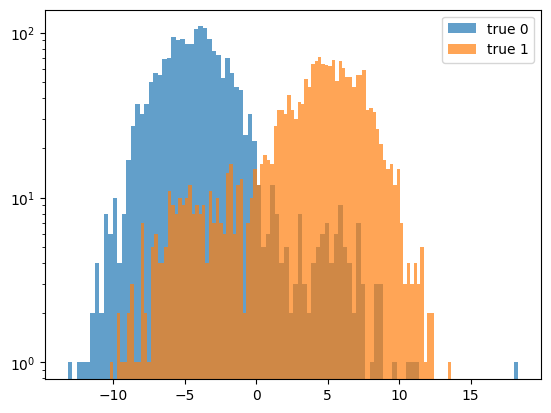

In [226]:
s_te, yhat_te = predict_full_filter(Xte, m_fis)
plt.hist(s_te[yte==0], bins=100, alpha=0.7, label="true 0")
plt.hist(s_te[yte==1], bins=100, alpha=0.7, label="true 1")
plt.yscale('log')
plt.legend()

In [227]:
import numpy as np
from scipy.optimize import minimize

def train_two_filters(
    X, y,
    l2=1e-4,
    smooth=1e-2,
    maxiter=500,
    objective="softmax",   # "softmax" | "hinge_ova" | "fisher2"
    class_weight=None      # None or {0:w0, 1:w1}
):
    """
    Learn two full-length filters f0,f1 and biases b0,b1.
    X: (n_shots, T), y in {0,1}
    """
    X = np.asarray(X, float)
    y = np.asarray(y).astype(int)
    n, T = X.shape

    # sample weights
    if class_weight is None:
        w = np.ones(n, dtype=float)
    else:
        w0 = float(class_weight.get(0, 1.0))
        w1 = float(class_weight.get(1, 1.0))
        w = np.where(y == 0, w0, w1).astype(float)
    w /= (w.mean() + 1e-12)

    # smoothness operator
    if T >= 3:
        D = np.zeros((T-2, T))
        for i in range(T-2):
            D[i, i:i+3] = [1.0, -2.0, 1.0]
    else:
        D = np.zeros((1, T))
    DtD = D.T @ D

    def unpack(theta):
        f0 = theta[:T]
        f1 = theta[T:2*T]
        b0 = theta[2*T]
        b1 = theta[2*T+1]
        return f0, f1, b0, b1

    def pack(f0, f1, b0, b1):
        return np.concatenate([f0, f1, [b0, b1]])

    def softmax2(a0, a1):
        m = np.maximum(a0, a1)
        e0 = np.exp(a0 - m)
        e1 = np.exp(a1 - m)
        z = e0 + e1
        return e0 / z, e1 / z

    # closed-form-ish fisher initialization / solution
    if objective == "fisher2":
        X0, X1 = X[y == 0], X[y == 1]
        mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)
        C0 = np.cov(X0, rowvar=False)
        C1 = np.cov(X1, rowvar=False)
        Sw = 0.5 * (C0 + C1) + l2*np.eye(T) + smooth*DtD

        f0 = np.linalg.solve(Sw, mu0)
        f1 = np.linalg.solve(Sw, mu1)
        b0 = -0.5 * mu0 @ f0
        b1 = -0.5 * mu1 @ f1
        return {"f0": f0, "f1": f1, "b0": float(b0), "b1": float(b1), "objective": "fisher2", "opt": None}

    def loss_grad(theta):
        f0, f1, b0, b1 = unpack(theta)

        a0 = X @ f0 + b0
        a1 = X @ f1 + b1

        if objective == "softmax":
            p0, p1 = softmax2(a0, a1)
            t0 = (y == 0).astype(float)
            t1 = 1.0 - t0

            eps = 1e-12
            nll = -np.mean(w * np.log(np.where(y == 0, p0, p1) + eps))

            g0 = (w * (p0 - t0)) / n
            g1 = (w * (p1 - t1)) / n

            gf0 = X.T @ g0
            gf1 = X.T @ g1
            gb0 = np.sum(g0)
            gb1 = np.sum(g1)
            loss = nll

        elif objective == "hinge_ova":
            # one-vs-all squared hinge on each score
            y0 = np.where(y == 0, 1.0, -1.0)
            y1 = np.where(y == 1, 1.0, -1.0)

            z0 = 1.0 - y0 * a0
            z1 = 1.0 - y1 * a1
            m0 = (z0 > 0).astype(float)
            m1 = (z1 > 0).astype(float)

            loss = np.mean(w * ((z0*m0)**2 + (z1*m1)**2))

            c0 = (-2.0 * w * z0 * m0 * y0) / n
            c1 = (-2.0 * w * z1 * m1 * y1) / n

            gf0 = X.T @ c0
            gf1 = X.T @ c1
            gb0 = np.sum(c0)
            gb1 = np.sum(c1)

        else:
            raise ValueError("objective must be 'softmax', 'hinge_ova', or 'fisher2'")

        # regularization on both filters
        loss += l2 * (f0 @ f0 + f1 @ f1)
        loss += smooth * (f0 @ DtD @ f0 + f1 @ DtD @ f1)

        gf0 += 2.0*l2*f0 + 2.0*smooth*(DtD @ f0)
        gf1 += 2.0*l2*f1 + 2.0*smooth*(DtD @ f1)

        grad = pack(gf0, gf1, gb0, gb1)
        return float(loss), grad

    # init from fisher2 tends to stabilize optimization
    init = train_two_filters(X, y, l2=l2, smooth=smooth, objective="fisher2")
    theta0 = pack(init["f0"], init["f1"], init["b0"], init["b1"])

    res = minimize(
        fun=lambda th: loss_grad(th)[0],
        x0=theta0,
        jac=lambda th: loss_grad(th)[1],
        method="L-BFGS-B",
        options={"maxiter": int(maxiter)}
    )

    f0, f1, b0, b1 = unpack(res.x)
    return {"f0": f0, "f1": f1, "b0": float(b0), "b1": float(b1), "objective": objective, "opt": res}

def predict_two_filters(X, model):
    X = np.asarray(X, float)
    S0 = X @ model["f0"] + model["b0"]
    S1 = X @ model["f1"] + model["b1"]
    yhat = (S1 > S0).astype(int)
    return S0, S1, yhat

m_soft = train_two_filters(Xtr, ytr, objective="softmax",   l2=1e-4, smooth=1e-3)
m_hing = train_two_filters(Xtr, ytr, objective="hinge_ova", l2=1e-4, smooth=1e-3)
m_fish = train_two_filters(Xtr, ytr, objective="fisher2",   l2=1e-4, smooth=1e-3)


In [228]:
for model in [m_soft, m_hing, m_fish]:
    S0_te, S1_te, yhat_te = predict_two_filters(Xte, model)
    print(f"test balanced acc ({model['objective']}) =", balanced_accuracy_score(yte, yhat_te))

test balanced acc (softmax) = 0.877
test balanced acc (hinge_ova) = 0.8725
test balanced acc (fisher2) = 0.895


(-5.0, 40.0)

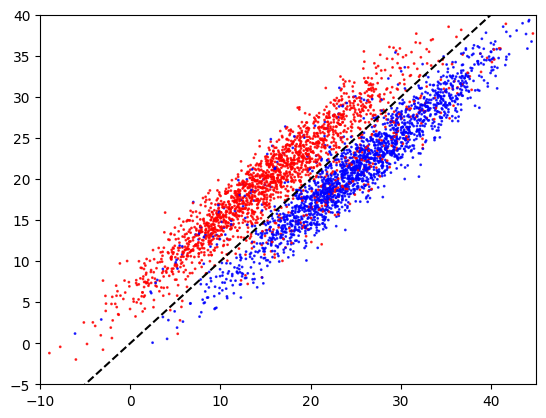

In [235]:
S0_te, S1_te, yhat_te = predict_two_filters(Xte, m_fish)

plt.scatter( S0_te, S1_te, c=yte, alpha=0.8, s=1.0, cmap='bwr')
plt.plot([S0_te.min(), S0_te.max()], [S0_te.min(), S0_te.max()], 'k--')
plt.xlim((-10,45))
plt.ylim((-5,40))

In [252]:
# --- Step 0: imports ---
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, accuracy_score, confusion_matrix

# ---------------------------
# 1) fast closed-form filter
# ---------------------------
def fisher_base_filter(X, y, reg=1e-3):
    # X: (N,T), y in {0,1}
    X0, X1 = X[y == 0], X[y == 1]
    mu0, mu1 = X0.mean(0), X1.mean(0)
    C0 = np.cov(X0, rowvar=False)
    C1 = np.cov(X1, rowvar=False)
    Sw = 0.5 * (C0 + C1)
    T = X.shape[1]
    f = np.linalg.solve(Sw + reg * np.eye(T), (mu1 - mu0))
    return f, mu0, mu1

# ---------------------------------------------
# 2) moving-frame local discrimination score c_k
# ---------------------------------------------
def moving_window_contrib(X, y, win=200, step=20, reg=1e-3):
    N, T = X.shape
    starts = list(range(0, T - win + 1, step))
    scores = []

    for s in starts:
        e = s + win
        Xw = X[:, s:e]
        X0, X1 = Xw[y == 0], Xw[y == 1]
        if len(X0) < 2 or len(X1) < 2:
            scores.append(0.0)
            continue
        mu0, mu1 = X0.mean(0), X1.mean(0)
        dmu = mu1 - mu0
        C0 = np.cov(X0, rowvar=False)
        C1 = np.cov(X1, rowvar=False)
        Sw = 0.5 * (C0 + C1)
        # local Fisher criterion (bigger => better discrimination)
        val = float(dmu @ np.linalg.solve(Sw + reg * np.eye(win), dmu))
        scores.append(max(val, 0.0))

    return np.array(starts), np.array(scores)

# ---------------------------------------------------
# 3) window scores -> sample-level temporal envelope w
# ---------------------------------------------------
def window_scores_to_weights(T, starts, c, win, smooth_sigma=10, eps=1e-12):
    w = np.zeros(T, dtype=float)
    n = np.zeros(T, dtype=float)

    for s, cs in zip(starts, c):
        e = s + win
        w[s:e] += cs
        n[s:e] += 1.0

    w = w / np.maximum(n, 1.0)

    # gaussian smoothing via conv
    if smooth_sigma > 0:
        r = int(4 * smooth_sigma)
        x = np.arange(-r, r + 1)
        g = np.exp(-(x**2) / (2 * smooth_sigma**2))
        g /= g.sum()
        w = np.convolve(w, g, mode="same")

    # normalize to [0,1], keep floor so no region is completely zeroed
    w = (w - w.min()) / (w.max() - w.min() + eps)
    w = 0.2 + 0.8 * w
    return w

# ------------------------------------------
# 5) torch fine-tune from weighted init f_init
# ------------------------------------------
def train_filter_torch(
    X, y, f_init, b_init,
    lr=1e-2, epochs=300,
    l2=1e-4, smooth=1e-2,
    class_weight=None,
    device=None
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    y_t = torch.tensor(y, dtype=torch.float32, device=device)  # 0/1
    N, T = X.shape

    f = torch.tensor(f_init, dtype=torch.float32, device=device, requires_grad=True)
    b = torch.zeros(1, dtype=torch.float32, device=device, requires_grad=True)

    # class weighting
    if class_weight is None:
        w = torch.ones_like(y_t)
    else:
        w0 = float(class_weight.get(0, 1.0))
        w1 = float(class_weight.get(1, 1.0))
        w = torch.where(y_t > 0.5, torch.tensor(w1, device=device), torch.tensor(w0, device=device))

    opt = torch.optim.Adam([f, b], lr=lr)

    for _ in range(epochs):
        opt.zero_grad()
        logits = X_t @ f + b  # (N,)

        # weighted BCE
        loss_vec = F.binary_cross_entropy_with_logits(logits, y_t, reduction="none")
        data_loss = (w * loss_vec).mean()

        # L2 + smoothness (second diff)
        d2 = f[:-2] - 2 * f[1:-1] + f[2:] if T >= 3 else torch.tensor(0.0, device=device)
        reg_loss = l2 * (f @ f) + smooth * (d2 @ d2 if T >= 3 else 0.0)

        loss = data_loss + reg_loss
        loss.backward()
        opt.step()

    return {
        "f": f.detach().cpu().numpy(),
        "b": float(b.detach().cpu().item()),
        "device": device
    }

def predict_filter(X, model):
    s = X @ model["f"] + model["b"]
    yhat = (s >= 0).astype(int)
    return s, yhat

def eval_cls(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    F00 = cm[0,0] / max(cm[0].sum(), 1)
    F11 = cm[1,1] / max(cm[1].sum(), 1)
    return {
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "acc": accuracy_score(y_true, y_pred),
        "F00": F00, "F11": F11, "cm": cm
    }

# --- End-to-end usage ---
# X: (n_shots, T), y: (n_shots,) in {0,1}
Xtr, Xte, ytr, yte = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# 1) fast base filter
f_base, _, _ = fisher_base_filter(Xtr, ytr, reg=1e-3)

# 2) moving-frame contributions
win, step = 300, 20
starts, c = moving_window_contrib(Xtr, ytr, win=win, step=step, reg=1e-3)

# 3) temporal weights
w = window_scores_to_weights(T=Xtr.shape[1], starts=starts, c=c, win=win, smooth_sigma=12)

# 4) weighted init
f_init = f_base * w

b_init = -0.5 * (Xtr[ytr==0].mean(axis=0) + Xtr[ytr==1].mean(axis=0)) @ f_init 

# 5) ML fine-tune
model = train_filter_torch(
    Xtr, ytr, f_init, b_init,
    lr=5e-3, epochs=400,
    l2=1e-4, smooth=1e-2,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# evaluate
_, yhat = predict_filter(Xte, model)
print(eval_cls(yte, yhat))


{'balanced_acc': 0.86375, 'acc': 0.86375, 'F00': np.float64(0.9015), 'F11': np.float64(0.826), 'cm': array([[1803,  197],
       [ 348, 1652]])}


In [251]:

b_init = -0.5 * (Xtr[ytr==0].mean(axis=0) + Xtr[ytr==1].mean(axis=0)) @ f_init 

# evaluate
_, yhat = predict_filter(Xte, {"f": f_init, "b": b_init})
print(eval_cls(yte, yhat))

{'balanced_acc': 0.886, 'acc': 0.886, 'F00': np.float64(0.9225), 'F11': np.float64(0.8495), 'cm': array([[1845,  155],
       [ 301, 1699]])}


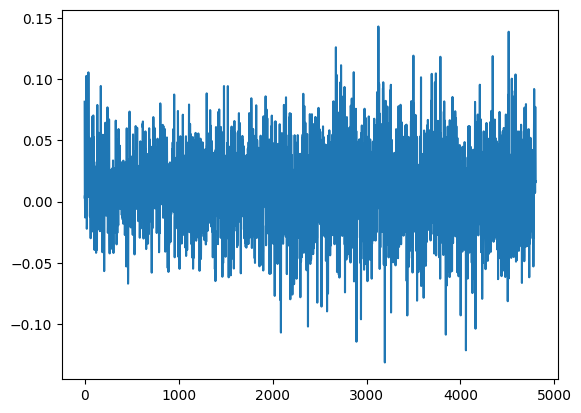

In [240]:
plt.plot(model["f"])

In [70]:
10**((41.969104-27.827445)/10)/2, 10**((35.237465-27.906703)/10)/2

(12.975852624976229, 2.704246051961528)

In [ ]:
def shot_snr_at_fixed_peaks(psd_shots, peak_idx_list, side_bins=80, guard_bins=6, sig_bins=1, eps=1e-30):
    """
    psd_shots: (n_shots, n_freq) linear PSD
    peak_idx_list: list of target peak indices from mean PSD
    returns:
      snr_db_each_peak: (n_shots, n_peaks)
      snr_db_combined:  (n_shots,)
    """
    P = np.asarray(psd_shots, float)
    n_shots, n_freq = P.shape
    peak_idx_list = [int(i) for i in peak_idx_list]
    out = []

    for p in peak_idx_list:
        # signal band around fixed peak bin
        i0 = max(0, p - sig_bins)
        i1 = min(n_freq, p + sig_bins + 1)
        psig = P[:, i0:i1].mean(axis=1)

        # sideband noise (exclude guard around peak)
        l0 = max(0, p - side_bins)
        l1 = max(0, p - guard_bins)
        r0 = min(n_freq, p + guard_bins + 1)
        r1 = min(n_freq, p + side_bins + 1)

        noise_bins = []
        if l1 > l0:
            noise_bins.append(P[:, l0:l1])
        if r1 > r0:
            noise_bins.append(P[:, r0:r1])
        pnoise = np.median(np.concatenate(noise_bins, axis=1), axis=1)

        snr_lin = np.maximum((psig - pnoise) / (pnoise + eps), eps)
        out.append(snr_lin)

    snr_each_peak = np.stack(out, axis=1)              # (shots, peaks)
    snr_combined = snr_each_peak.mean(axis=1)       # simple combine
    return snr_each_peak, snr_combined


snr_each_peak, snr_combined = shot_snr_at_fixed_peaks(psd, [1031])

np.mean(snr_each_peak[y==0,:], axis=0), np.mean(snr_each_peak[y==1,:], axis=0)

(array([13.53309577]), array([5.20002389]))

In [5]:
from scipy import special

Phi = lambda x : 0.5 * ( 1 + special.erf(x/np.sqrt(2)) )

Phi((10**(r0[2]['snr_db']/10/2)-10**(r1[2]['snr_db']/10/2))/2)

np.float64(0.9168716806297124)

In [ ]:
import numpy as np
from src.readout.experiments import (
    compute_psd_rfft, 
    scores_from_psd_using_median_floor, 
    train_test_fidelity_from_scores
)

# 2) 选目标峰（示例：用两类平均 PSD 差最大处）
m0 = psd[y == 0].mean(axis=0)
m1 = psd[y == 1].mean(axis=0)
peak_idx = int(np.argmax(np.abs(m0 - m1)))

# 3) 把每个 shot 变成 1D score（峰高减噪声底）
scores = scores_from_psd_using_median_floor(psd, peak_idx, noise_med_window_bins=401, fast=True)
# 4) 训练/测试分离评估 fidelity
out = train_test_fidelity_from_scores(scores, y, train_ratio=0.8, seed=42, stratified=True)
out


{'train': {'F0_to_0': 0.9415,
  'F1_to_1': 0.851625,
  'threshold': 11.963069059045713,
  'direction': 'predict_1_if_s_le_t',
  'balanced_acc': 0.8965624999999999,
  'n_train': 16000,
  'n_train_class0': 8000,
  'n_train_class1': 8000},
 'test': {'F0_to_0': 0.936,
  'F1_to_1': 0.854,
  'balanced_acc': 0.895,
  'acc': 0.895,
  'n_test': 4000,
  'n_test_class0': 2000,
  'n_test_class1': 2000}}

In [14]:
import numpy as np

def estimate_shot_snr_from_overall_spectrum(
    peak_psd_db_overall,
    noise_floor_db_overall,
    n_shots,
    mode="mean_trace",  # "mean_trace" or "mean_psd"
):
    """
    Approximate single-shot SNR from overall spectrum.

    mode="mean_trace": overall spectrum from PSD(mean of time traces)
        => SNR_single ~= SNR_overall / n_shots (linear)
    mode="mean_psd": overall spectrum from mean of per-shot PSD
        => no coherent gain; SNR_single ~= SNR_overall
    """
    snr_overall_lin = 10.0 ** ((peak_psd_db_overall - noise_floor_db_overall) / 10.0)

    if mode == "mean_trace":
        snr_shot_lin = snr_overall_lin / max(int(n_shots), 1)
    elif mode == "mean_psd":
        snr_shot_lin = snr_overall_lin
    else:
        raise ValueError("mode must be 'mean_trace' or 'mean_psd'")

    snr_shot_db = 10.0 * np.log10(np.maximum(snr_shot_lin, 1e-30))
    return {"snr_overall_lin": snr_overall_lin, "snr_shot_lin": snr_shot_lin, "snr_shot_db": snr_shot_db}

# Approximate shot SNR from overall spectrum
est0 = estimate_shot_snr_from_overall_spectrum(r0[2]["peak_psd_db"], r0[2]["noise_floor_db"], n_shots=10000, mode="mean_trace")
est1 = estimate_shot_snr_from_overall_spectrum(r1[2]["peak_psd_db"], r1[2]["noise_floor_db"], n_shots=10000, mode="mean_trace")

est0, est1

({'snr_overall_lin': 25.95170480580061,
  'snr_shot_lin': 0.002595170480580061,
  'snr_shot_db': np.float64(-25.858341074327562)},
 {'snr_overall_lin': 5.408491615769465,
  'snr_shot_lin': 0.0005408491615769465,
  'snr_shot_db': np.float64(-32.66923839198064)})

In [ ]:
import numpy as np
from scipy.stats import gamma
import numpy as np
from scipy.stats import gamma

def spam_from_snr_fwhm_gamma(
    snr0_shot_db, snr1_shot_db,              # scalar or array-like (shot-level SNR in dB)
    noise_floor_lin,
    fwhm_hz=None,
    rbw_hz=None,
    n_avg=1,
    p0=0.5, p1=0.5,
    grid_size=5000,
):
    """
    Gamma-model SPAM estimate using shot-level SNR info.
    If snr*_shot_db are arrays, it uses their distribution moments (more realistic).
    """
    def _to_1d(a):
        x = np.asarray(a, dtype=float)
        return x.reshape(-1)

    def _snr_db_to_linear(snr_db):
        return 10.0 ** (np.asarray(snr_db, dtype=float) / 10.0)

    def _moment_k(x):
        x = np.asarray(x, dtype=float)
        m = float(np.mean(x))
        v = float(np.var(x, ddof=1)) if x.size > 1 else 0.0
        if v <= 0.0:
            return np.inf
        return max(1.0, m * m / v)


    s0_db = _to_1d(snr0_shot_db)
    s1_db = _to_1d(snr1_shot_db)
    s0_lin = _snr_db_to_linear(s0_db)
    s1_lin = _snr_db_to_linear(s1_db)

    # Per-shot peak power samples implied by SNR samples
    x0 = noise_floor_lin * (1.0 + s0_lin)
    x1 = noise_floor_lin * (1.0 + s1_lin)

    # Means from shot-level samples
    mu0 = float(np.mean(x0))
    mu1 = float(np.mean(x1))

    # Bandwidth averaging factor
    n_bin = 1
    if (fwhm_hz is not None) and (rbw_hz is not None) and (rbw_hz > 0):
        n_bin = max(1, int(round(float(fwhm_hz) / float(rbw_hz))))
    k_avg = max(1.0, float(n_avg * n_bin))

    # Effective shape from shot fluctuations (moment match), then include averaging factor
    k0_shot = _moment_k(x0) if x0.size > 1 else np.inf
    k1_shot = _moment_k(x1) if x1.size > 1 else np.inf
    k0 = k_avg if np.isinf(k0_shot) else max(1.0, k_avg * k0_shot)
    k1 = k_avg if np.isinf(k1_shot) else max(1.0, k_avg * k1_shot)

    th0 = mu0 / k0
    th1 = mu1 / k1

    d0 = gamma(a=k0, scale=th0)
    d1 = gamma(a=k1, scale=th1)

    lo = min(d0.ppf(1e-6), d1.ppf(1e-6))
    hi = max(d0.ppf(1 - 1e-6), d1.ppf(1 - 1e-6))
    t_grid = np.linspace(lo, hi, int(grid_size))

    p0, p1 = float(p0), float(p1)
    z = p0 + p1
    p0, p1 = p0 / z, p1 / z

    c0 = d0.cdf(t_grid)
    c1 = d1.cdf(t_grid)

    F0a, F1a = c0, 1.0 - c1
    Fa = p0 * F0a + p1 * F1a
    ia = int(np.argmax(Fa))

    F0b, F1b = 1.0 - c0, c1
    Fb = p0 * F0b + p1 * F1b
    ib = int(np.argmax(Fb))

    if Fa[ia] >= Fb[ib]:
        t, F00, F11, F = float(t_grid[ia]), float(F0a[ia]), float(F1a[ia]), float(Fa[ia])
        direction = "predict_1_if_s_ge_t"
    else:
        t, F00, F11, F = float(t_grid[ib]), float(F0b[ib]), float(F1b[ib]), float(Fb[ib])
        direction = "predict_1_if_s_le_t"

    return {
        "t": t, "direction": direction,
        "F00": F00, "F11": F11, "F": F,
        "e0": 1.0 - F00, "e1": 1.0 - F11,
        "mu0": mu0, "mu1": mu1,
        "gamma_shape_k0": float(k0), "gamma_shape_k1": float(k1),
        "theta0": float(th0), "theta1": float(th1),
        "n_bin": int(n_bin),
    }

# est0 = estimate_shot_snr_from_overall_spectrum(peak0_db, noise0_db, n_shots=10000, mode="mean_trace")
# est1 = estimate_shot_snr_from_overall_spectrum(peak1_db, noise1_db, n_shots=10000, mode="mean_trace")


out = spam_from_snr_fwhm_gamma(
    snr0_shot_db=0.002595170480580061,
    snr1_shot_db=0.0005408491615769465,
    noise_floor_lin=1.2e3,
    fwhm_hz=2.0e6,
    rbw_hz=0.2e6,
    n_avg=4,
    p0=0.5, p1=0.5,
    grid_size=5000,
)
out


{'t': 10927.835884555678,
 'direction': 'predict_1_if_s_le_t',
 'F00': 0.9997446311145497,
 'F11': 0.9998263258644825,
 'F': 0.9997854784895162,
 'e0': 0.00025536888545030223,
 'e1': 0.00017367413551749866,
 'mu0': 20218.71830953336,
 'mu1': 6560.203105811558,
 'gamma_shape_k': 40.0,
 'theta0': 505.467957738334,
 'theta1': 164.00507764528896,
 'n_bin': 10}

In [ ]:
({'snr_overall_lin': 25.95170480580061,
  'snr_shot_lin': 0.002595170480580061,
  'snr_shot_db': np.float64(-25.858341074327562)},
 {'snr_overall_lin': 5.408491615769465,
  'snr_shot_lin': 0.0005408491615769465,
  'snr_shot_db': np.float64(-32.66923839198064)})

In [5]:

from src.readout.experiments import metrics_from_peaks_gennorm

mu0, mu1 = r0[2]["f0_hz"], r1[2]["f0_hz"]
fwhm0, fwhm1 = r0[2]["fwhm_hz"], r1[2]["fwhm_hz"]

# 3) 非高斯模型估计读出/SPAM
out = metrics_from_peaks_gennorm(
    mu0=mu0, width0=fwhm0,
    mu1=mu1, width1=fwhm1,
    width_level=0.5,   # FWHM
    p0=0.5, p1=0.5
)
out

{'threshold': 759285974.3570088,
 'direction': 'predict_1_if_s_ge_t',
 'F0_to_0': 0.1643269836109806,
 'F1_to_1': 0.8467807750705365,
 'F': 0.5055538793407586,
 'e0': 0.8356730163890194,
 'e1': 0.1532192249294635,
 'p0': 0.5,
 'p1': 0.5,
 'mu0': 759684210.5263158,
 'mu1': 759684210.5263158,
 'alpha0': np.float64(576550.4169521083),
 'alpha1': np.float64(550677.5001286563),
 'beta0': 2.0,
 'beta1': 2.0,
 'sigma0_equiv': 407682.70952276717,
 'sigma1_equiv': 389387.7945878288,
 'width_level': 0.5}

In [ ]:
import numpy as np
from math import erf, sqrt

def Phi(z):
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))

def metrics_from_gaussians(mu0, sig0, mu1, sig1, p0=0.5, p1=0.5, pick="best"):
    """
    x|0 ~ N(mu0, sig0^2), x|1 ~ N(mu1, sig1^2)
    Decision: predict 0 if x >= t else 1 (we'll enforce mu0 >= mu1 by swapping if needed)
    Returns: t, F00, F11, Favg_weighted
    """
    mu0, mu1, sig0, sig1 = map(float, [mu0, mu1, sig0, sig1])
    p0, p1 = float(p0), float(p1)
    assert sig0 > 0 and sig1 > 0 and p0 > 0 and p1 > 0

    swapped = False
    if mu0 < mu1:
        # swap labels so that mu0 >= mu1
        mu0, mu1 = mu1, mu0
        sig0, sig1 = sig1, sig0
        p0, p1 = p1, p0
        swapped = True

    # Solve for optimal threshold(s)
    if abs(sig0 - sig1) < 1e-15:
        # equal-variance closed form
        sig = sig0
        t_candidates = [0.5*(mu0+mu1) + (sig*sig/(mu0-mu1))*np.log(p1/p0)]
    else:
        # quadratic: A t^2 + B t + C = 0
        a = 1.0/(2.0*sig0*sig0)
        b = 1.0/(2.0*sig1*sig1)
        k = np.log((sig1*p0)/(sig0*p1))

        A = a - b
        B = (-2*a*mu0 + 2*b*mu1)
        C = (a*mu0*mu0 - b*mu1*mu1 - k)

        disc = B*B - 4*A*C
        t_candidates = []
        if disc >= 0:
            rdisc = np.sqrt(disc)
            t_candidates = [(-B + rdisc)/(2*A), (-B - rdisc)/(2*A)]

        # fallback: if numerical weirdness gives no real roots, use midpoint
        if len(t_candidates) == 0:
            t_candidates = [0.5*(mu0+mu1)]

    def eval_at_t(t):
        F00 = Phi((mu0 - t)/sig0)          # P(x>=t|0)
        F11 = Phi((t - mu1)/sig1)          # P(x<t |1)
        F = p0*F00 + p1*F11
        return F, F00, F11

    # pick best candidate (or one between means)
    scored = [(eval_at_t(t)[0], t, *eval_at_t(t)[1:]) for t in t_candidates]
    if pick == "between":
        between = [s for s in scored if (mu1 <= s[1] <= mu0)]
        scored = between if between else scored

    best = max(scored, key=lambda x: x[0])
    F, t_star, F00, F11 = best

    # if we swapped labels, map back (optional)
    if swapped:
        # original F00 was actually F11 and vice versa because we swapped class meaning
        # but also decision rule flips label meaning; simplest: just report with original labels:
        # Here we return "correct for original 0/1" by swapping back:
        F00, F11 = F11, F00
        # For completeness, t_star is still threshold on x; it doesn't change.

    return dict(t=t_star, F00=F00, F11=F11, F=F)


# Example:
out = metrics_from_gaussians(
    np.sqrt(10**(r0[2]["peak_psd_db"]/10)-10**(r0[2]["noise_floor_db"]/10)), 10**(r0[2]["noise_floor_db"]/10/2)/np.sqrt(2), 
    np.sqrt(10**(r1[2]["peak_psd_db"]/10)-10**(r1[2]["noise_floor_db"]/10)), 10**(r1[2]["noise_floor_db"]/10/2)/np.sqrt(2), p0=0.5, p1=0.5)
print(out)

{'t': np.float64(87.71316030516329), 'F00': 0.9786596896611013, 'F11': 0.978428083501538, 'F': 0.9785438865813196}


In [31]:
10**(r0[2]["peak_psd_db"]/10)
# 10**(r1[2]["peak_psd_db"]/10)
# 10**(r0[2]["noise_floor_db"]/10)
# 10**(r1[2]["noise_floor_db"]/10)

15736.580468132084

In [17]:
def fidelity_from_mean_psd_at_bin(mu0, mu1, assume_mu0_greater=True):
    """
    mu0, mu1: two states' mean single-shot power at the target bin (linear units, not dB)
    Returns: threshold t*, F0->0, F1->1, average fidelity F (equal priors)
    """
    mu0 = float(mu0); mu1 = float(mu1)
    if mu0 <= 0 or mu1 <= 0:
        raise ValueError("mu0/mu1 must be positive (linear power).")

    # Ensure labeling matches rule "X > t => pick higher-mean state"
    if assume_mu0_greater:
        hi_mu, lo_mu = mu0, mu1
        hi_label = 0
    else:
        hi_mu, lo_mu = mu1, mu0
        hi_label = 1

    if np.isclose(hi_mu, lo_mu):
        return dict(t_star=np.nan, F00=0.5, F11=0.5, F=0.5, hi_label=hi_label)

    # optimal threshold for Exp(means)
    t = (hi_mu * lo_mu) / (lo_mu - hi_mu) * np.log(lo_mu / hi_mu)

    # correctness for higher-mean state (choose hi when X>t)
    F_hi = np.exp(-t / hi_mu)

    # correctness for lower-mean state (choose lo when X<=t)
    F_lo = 1.0 - np.exp(-t / lo_mu)

    # Map back to F0->0, F1->1
    if hi_label == 0:
        F00, F11 = F_hi, F_lo
    else:
        F00, F11 = F_lo, F_hi

    F = 0.5 * (F00 + F11)
    return dict(t_star=t, F00=F00, F11=F11, F=F)

fidelity_from_mean_psd_at_bin(10**(r0[2]["peak_psd_db"]/10), 10**(r1[2]["peak_psd_db"]/10) )

{'t_star': np.float64(6571.907538779887),
 'F00': np.float64(0.6586125873848947),
 'F11': np.float64(0.8602132074842164),
 'F': np.float64(0.7594128974345555)}

In [24]:
10**(r1[2]["peak_psd_db"]/10)

3340.0001016396654

In [21]:
from scipy.special import gammainc  # regularized lower incomplete gamma P(a, x)

def _gamma_cdf(x: np.ndarray, alpha: float, theta: float) -> np.ndarray:
    """CDF of Gamma(shape=alpha, scale=theta) using regularized gammainc."""
    x = np.asarray(x, dtype=float)
    return gammainc(alpha, np.maximum(x, 0.0) / theta)

def estimate_common_alpha_mom(x0: np.ndarray, x1: np.ndarray) -> float:
    """
    Method-of-moments estimate of common Gamma shape alpha from pooled samples.
    For Gamma: var = mean^2 / alpha  => alpha = mean^2 / var
    """
    x = np.concatenate([np.asarray(x0, float).ravel(), np.asarray(x1, float).ravel()])
    m = float(np.mean(x))
    v = float(np.var(x, ddof=1))
    if m <= 0 or v <= 0:
        raise ValueError("Need positive mean and variance to estimate alpha.")
    return (m * m) / v

def gamma_threshold_equal_shape(mu0: float, mu1: float, alpha: float) -> float:
    """
    Optimal LRT threshold for Gamma with same shape alpha and different scales.
    Assumes equal priors and decision rule 'pick higher-mean state when X > t'.
    """
    mu0 = float(mu0); mu1 = float(mu1); alpha = float(alpha)
    if mu0 <= 0 or mu1 <= 0 or alpha <= 0:
        raise ValueError("mu0, mu1, alpha must be positive.")

    # Convert means to scales: mu = alpha * theta
    theta0 = mu0 / alpha
    theta1 = mu1 / alpha

    # If means equal => no discrimination
    if np.isclose(theta0, theta1):
        return np.nan

    # Closed-form threshold from log f0(x) = log f1(x):
    # x*(1/theta1 - 1/theta0) + alpha*log(theta1/theta0) = 0
    t = alpha * np.log(theta1 / theta0) / (1.0 / theta0 - 1.0 / theta1)
    return float(t)

def fidelity_from_gamma_bin(
    x0: np.ndarray,
    x1: np.ndarray,
    *,
    alpha: float | None = None,
    use_pooled_alpha: bool = True,
):
    """
    Given samples of single-shot power at one bin for state-0 and state-1,
    model them as Gamma with common shape alpha. Compute optimal threshold and fidelities.

    Returns:
      dict(t_star, F00, F11, F, alpha, mu0, mu1)
    """
    x0 = np.asarray(x0, float).ravel()
    x1 = np.asarray(x1, float).ravel()
    if np.any(x0 < 0) or np.any(x1 < 0):
        raise ValueError("Power samples must be nonnegative.")

    mu0 = float(np.mean(x0))
    mu1 = float(np.mean(x1))

    if alpha is None:
        if not use_pooled_alpha:
            # estimate alpha from each and average (less stable than pooled)
            a0 = (mu0 * mu0) / float(np.var(x0, ddof=1))
            a1 = (mu1 * mu1) / float(np.var(x1, ddof=1))
            alpha = 0.5 * (a0 + a1)
        else:
            alpha = estimate_common_alpha_mom(x0, x1)

    # Determine which state has larger mean (higher scale => stochastically larger)
    if mu0 >= mu1:
        hi = 0
        mu_hi, mu_lo = mu0, mu1
    else:
        hi = 1
        mu_hi, mu_lo = mu1, mu0

    t = gamma_threshold_equal_shape(mu_hi, mu_lo, alpha)

    # CDF params
    theta_hi = mu_hi / alpha
    theta_lo = mu_lo / alpha

    # Decision rule: choose higher-mean state if X > t
    # Correctness:
    #   F_hi = P(X > t | hi) = 1 - CDF_hi(t)
    #   F_lo = P(X <= t | lo) = CDF_lo(t)
    C_hi = _gamma_cdf(t, alpha, theta_hi)
    C_lo = _gamma_cdf(t, alpha, theta_lo)
    F_hi = 1.0 - float(C_hi)
    F_lo = float(C_lo)

    if hi == 0:
        F00, F11 = F_hi, F_lo
    else:
        F00, F11 = F_lo, F_hi

    F = 0.5 * (F00 + F11)
    return dict(t_star=t, F00=F00, F11=F11, F=F, alpha=float(alpha), mu0=mu0, mu1=mu1)

psd_0_760 = psd[y==0, r0[2]["peak_idx"]]  # 单次功率样本
psd_1_760 = psd[y==1, r0[2]["peak_idx"]]

res = fidelity_from_gamma_bin(psd_0_760, psd_1_760)  # 自动估 alpha（pooled MOM）
print(res)


{'t_star': 6571.907538779888, 'F00': 0.7190768056817389, 'F11': 0.8767718837254341, 'F': 0.7979243447035865, 'alpha': 1.3481060959771516, 'mu0': 15736.58046813205, 'mu1': 3340.0001016396686}


In [19]:

psd_0_760 = psd[y==0, r0[2]["peak_idx"]]  # 单态，单 bin

print("mean =", psd_0_760.mean())
print("std/mean =", psd_0_760.std() / psd_0_760.mean())

mean = 15736.58046813205
std/mean = 0.3535099561643768


In [ ]:
import numpy as np
from scipy.ndimage import median_filter
from scipy.signal import find_peaks, peak_widths

def scores_from_psd_using_median_floor(f, p, peak_idx, noise_med_window_bins=401):
    """
    对每一枪：复用你函数的核心(median_filter噪声底)。
    score_k = resid_db[peak_idx] = Pdb[peak_idx] - noise_floor_db[peak_idx]
    """
    if noise_med_window_bins % 2 == 0:
        noise_med_window_bins += 1

    Pdb = 10*np.log10(p + 1e-30)  # (n_shots, n_freq)
    noise_floor_db = median_filter(Pdb, size=(1, noise_med_window_bins), mode='nearest')
    resid_db = Pdb - noise_floor_db
    return resid_db[:, peak_idx]  # (n_shots,)

def scores_from_psd_using_median_floor_fast(p, peak_idx, noise_med_window_bins=401, eps=1e-30):
    """
    Fast version: only compute the median noise floor in a local window around peak_idx.
    Returns single-shot score = resid_db at peak_idx (dB).
    """
    p = np.asarray(p)
    W = int(noise_med_window_bins)
    if W % 2 == 0:
        W += 1
    h = W // 2

    # local window bounds (clip at edges)
    i0 = max(0, peak_idx - h)
    i1 = min(p.shape[1], peak_idx + h + 1)

    Pdb = 10.0 * np.log10(p + eps)          # (n_shots, n_freq)
    noise_floor_at_peak = np.median(Pdb[:, i0:i1], axis=1)  # (n_shots,)
    score = Pdb[:, peak_idx] - noise_floor_at_peak
    return score

def best_threshold_from_scores(scores, y):
    """在1D score上扫描阈值，返回最优 balanced accuracy 的阈值和方向，并给出 F0->0/F1->1。"""
    scores = np.asarray(scores, float)
    y = np.asarray(y).astype(int)
    s0, s1 = scores[y == 0], scores[y == 1]

    cand = np.sort(np.unique(np.r_[s0, s1]))
    thr = np.r_[cand[0]-1e-12, (cand[:-1]+cand[1:])/2, cand[-1]+1e-12]

    best = (-1.0, None, None)
    for t in thr:
        # predict 1 if s>=t
        F0 = (s0 < t).mean()
        F1 = (s1 >= t).mean()
        bacc = 0.5*(F0+F1)
        if bacc > best[0]:
            best = (float(bacc), float(t), "predict_1_if_s_ge_t")

        # predict 1 if s<=t
        F0 = (s0 > t).mean()
        F1 = (s1 <= t).mean()
        bacc = 0.5*(F0+F1)
        if bacc > best[0]:
            best = (float(bacc), float(t), "predict_1_if_s_le_t")

    bacc, t, direction = best
    if direction == "predict_1_if_s_ge_t":
        F0, F1 = float((s0 < t).mean()), float((s1 >= t).mean())
    else:
        F0, F1 = float((s0 > t).mean()), float((s1 <= t).mean())

    return {"F0_to_0": F0, "F1_to_1": F1, "threshold": t, "direction": direction, "balanced_acc": bacc}


def predict_fidelities_from_spectrum(freq, psd, y, peak_idx,
                                     prominence_db=6, noise_med_window_bins=401,
                                     f0_hint_hz=None):
    """
    总入口：
    1) single-shot PSD
    2) 用 mean PSD + 你的 peak_snr_and_width_from_psd 找 peak_idx
    3) 对每shot算 resid_db@peak_idx 当 score
    4) 阈值分类 → F0->0, F1->1
    """
    scores = scores_from_psd_using_median_floor_fast(freq, psd, peak_idx, noise_med_window_bins=noise_med_window_bins)
    out = best_threshold_from_scores(scores, y)
    out.update({
        "peak_idx": int(peak_idx),
        "peak_f0_hz": float(freq[peak_idx]),
        "scores": scores,
    })
    return out

In [12]:
window = (500,4800)
predict_fidelities_from_spectrum(freq, psd, y, r0[2]["peak_idx"])

{'F0_to_0': 0.9361,
 'F1_to_1': 0.8567,
 'threshold': 12.275916700583586,
 'direction': 'predict_1_if_s_le_t',
 'balanced_acc': 0.8964000000000001,
 'peak_idx': 1031,
 'peak_f0_hz': 759684210.5263158,
 'scores': array([17.72970269, 15.35136907, 15.19494373, ...,  6.04369477,
         3.57373834, 11.20838094], shape=(20000,))}

In [ ]:

s0_176 = scores_from_psd_using_median_floor_fast(
    np.abs(F0[:,mask])**2, r0[0]["peak_idx"]
)
s0_620 = scores_from_psd_using_median_floor_fast(
    np.abs(F0[:,mask])**2, r0[1]["peak_idx"]
)
s0_760 = scores_from_psd_using_median_floor_fast(
    np.abs(F0[:,mask])**2, r0[2]["peak_idx"]
)


s1_176 = scores_from_psd_using_median_floor_fast(
    np.abs(F1[:,mask])**2, r1[0]["peak_idx"]
)
s1_620 = scores_from_psd_using_median_floor_fast(
    np.abs(F1[:,mask])**2, r1[1]["peak_idx"]
)
s1_760 = scores_from_psd_using_median_floor_fast(
    np.abs(F1[:,mask])**2, r1[2]["peak_idx"]
)

scores = dict(
    s176=np.concatenate([s0_176, s1_176]),
    s620=np.concatenate([s0_620, s1_620]),
    s760=np.concatenate([s0_760, s1_760]),
)

In [ ]:

def analyze_score_correlations(scores: dict, y: np.ndarray):
    """
    scores: dict[str, np.ndarray], e.g.
        {
          "760": s760,
          "620": s620,
          "176": s176,
        }
    y: (n_shots,) labels 0/1

    returns: dict with correlation matrices
    """
    keys = list(scores.keys())
    X = np.vstack([scores[k] for k in keys])  # (n_features, n_shots)

    out = {}

    # 1) overall correlation
    out["corr_all"] = np.corrcoef(X)

    # 2) per-class correlation
    y = np.asarray(y).astype(int)
    for cls in [0, 1]:
        mask = (y == cls)
        if mask.sum() < 3:
            out[f"corr_class_{cls}"] = None
        else:
            out[f"corr_class_{cls}"] = np.corrcoef(X[:, mask])

    out["keys"] = keys
    return out

In [151]:
analyze_score_correlations(scores, y)

{'corr_all': array([[ 1.00000000e+00, -4.47123658e-03, -9.86593988e-04],
        [-4.47123658e-03,  1.00000000e+00,  7.36239702e-01],
        [-9.86593988e-04,  7.36239702e-01,  1.00000000e+00]]),
 'corr_class_0': array([[1.        , 0.00451057, 0.00799625],
        [0.00451057, 1.        , 0.82973471],
        [0.00799625, 0.82973471, 1.        ]]),
 'corr_class_1': array([[ 1.00000000e+00, -5.13767542e-03, -7.79678633e-04],
        [-5.13767542e-03,  1.00000000e+00,  3.97685038e-01],
        [-7.79678633e-04,  3.97685038e-01,  1.00000000e+00]]),
 'keys': ['s176', 's620', 's760']}

In [168]:
def resid_db_at_peak_fast(p, peak_idx, noise_med_window_bins=201, eps=1e-30):
    p = np.asarray(p)
    W = int(noise_med_window_bins)
    if W % 2 == 0: W += 1
    h = W // 2
    i0 = max(0, peak_idx - h)
    i1 = min(p.shape[1], peak_idx + h + 1)

    Pdb = 10.0 * np.log10(p + eps)
    noise_floor = np.median(Pdb[:, i0:i1], axis=1)
    return Pdb[:, peak_idx] - noise_floor  # (n_shots,)

def features_resid_multi_peak(p, peak_indices, noise_med_window_bins=201):
    feats = [resid_db_at_peak_fast(p, idx, noise_med_window_bins) for idx in peak_indices]
    return np.stack(feats, axis=1)  # (n_shots, n_peaks)

def lda_fit_predict(X, y, reg=1e-6, equal_priors=True):
    """
    X: (n, d), y: (n,)
    Returns: y_pred (n,)
    """
    X = np.asarray(X, float); y = np.asarray(y).astype(int)
    X0, X1 = X[y==0], X[y==1]
    mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)

    # pooled covariance
    C0 = np.cov(X0, rowvar=False, bias=False) if len(X0) > 1 else np.eye(X.shape[1])
    C1 = np.cov(X1, rowvar=False, bias=False) if len(X1) > 1 else np.eye(X.shape[1])
    Sp = ((len(X0)-1)*C0 + (len(X1)-1)*C1) / max(len(X0)+len(X1)-2, 1)

    # regularize
    Sp = Sp + reg*np.eye(Sp.shape[0])
    invSp = np.linalg.inv(Sp)

    w = invSp @ (mu1 - mu0)
    b = -0.5*(mu1 + mu0) @ w

    # priors
    if equal_priors:
        logpi1_over_pi0 = 0.0
    else:
        pi0 = max((y==0).mean(), 1e-12)
        pi1 = max((y==1).mean(), 1e-12)
        logpi1_over_pi0 = np.log(pi1/pi0)

    score = X @ w + b + logpi1_over_pi0
    y_pred = (score >= 0).astype(int)
    return y_pred

def fidelities_from_pred(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    m0 = (y_true == 0)
    m1 = (y_true == 1)

    F0 = float((y_pred[m0] == 0).mean()) if m0.any() else float("nan")
    F1 = float((y_pred[m1] == 1).mean()) if m1.any() else float("nan")

    acc = float((y_pred == y_true).mean())
    bacc = 0.5 * (F0 + F1)

    return {
        "F0_to_0": F0,
        "F1_to_1": F1,
        "acc": acc,
        "balanced_acc": float(bacc),
    }

# peak_idxs = [271,952,1167]
peak_idxs = [271,952,1167]
p = np.concatenate([np.abs(F0[:,mask])**2,np.abs(F1[:,mask])**2],axis=0)
Xfeat = features_resid_multi_peak(p, peak_idxs, noise_med_window_bins=201)
y_pred = lda_fit_predict(Xfeat, y)
print(fidelities_from_pred(y, y_pred))

{'F0_to_0': 0.9479, 'F1_to_1': 0.8135, 'acc': 0.8807, 'balanced_acc': 0.8807}


In [155]:
display([r0[i]["peak_idx"] for i in range(3)])
display([r1[i]["peak_idx"] for i in range(3)])

[np.int64(270), np.int64(952), np.int64(1167)]

[np.int64(271), np.int64(952), np.int64(1166)]

In [170]:
def features_complex_peaks(X, peak_indices):
    X = np.asarray(X)  # complex, (n_shots, n_freq)
    feats = []
    for idx in peak_indices:
        z = X[:, idx]
        feats.append(np.real(z))
        feats.append(np.imag(z))
    return np.stack(feats, axis=1)  # (n_shots, 2*n_peaks)

peak_idxs = [1166,1167]
Xfeat = features_complex_peaks(p, peak_idxs)
y_pred = lda_fit_predict(Xfeat, y)
print(fidelities_from_pred(y, y_pred))

{'F0_to_0': 0.8996, 'F1_to_1': 0.8681, 'acc': 0.88385, 'balanced_acc': 0.88385}


In [163]:
def features_projected_scores(X, y, peak_indices, eps=1e-12):
    """
    X: complex FFT (n_shots, n_freq)
    returns: real features (n_shots, n_peaks)
    """
    X = np.asarray(X)
    y = np.asarray(y).astype(int)
    feats = []
    for idx in peak_indices:
        z = X[:, idx]
        mu0 = z[y==0].mean()
        mu1 = z[y==1].mean()
        d = mu1 - mu0
        u = d / (np.abs(d) + eps)     # unit direction
        s = np.real(np.conj(u) * z)   # projected score
        feats.append(s)
    return np.stack(feats, axis=1)

Xfeat = features_projected_scores(p, y, peak_idxs)
y_pred = lda_fit_predict(Xfeat, y)
print(fidelities_from_pred(y, y_pred))

{'F0_to_0': 0.8948, 'F1_to_1': 0.8707, 'acc': 0.88275, 'balanced_acc': 0.88275}


In [114]:
from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, Literal

@dataclass
class SpectralFidelityResult:
    # decision
    threshold: float
    direction: Literal["predict_1_if_score_ge_t", "predict_1_if_score_le_t"]

    # fidelities
    F0_to_0: float
    F1_to_1: float
    acc: float
    balanced_acc: float

    # debug / stats
    score0_mean: float
    score1_mean: float
    score0_std: float
    score1_std: float
    scores0: np.ndarray
    scores1: np.ndarray


def _rfft_freqs(fs: float, n: int) -> np.ndarray:
    return np.fft.rfftfreq(n, d=1.0/fs)


def _choose_threshold_empirical(
    s0: np.ndarray,
    s1: np.ndarray,
    objective: Literal["balanced_acc", "min_error"] = "balanced_acc",
) -> Tuple[float, Literal["predict_1_if_score_ge_t", "predict_1_if_score_le_t"]]:
    """
    Find best threshold t and direction on 1D score with an empirical scan.
    - direction decides whether larger score means class=1 or class=0.
    """
    s0 = np.asarray(s0, dtype=float)
    s1 = np.asarray(s1, dtype=float)

    # candidate thresholds: midpoints between sorted unique scores
    all_s = np.sort(np.unique(np.concatenate([s0, s1])))
    if all_s.size == 1:
        # degenerate: everything same score
        return float(all_s[0]), "predict_1_if_score_ge_t"

    mids = (all_s[:-1] + all_s[1:]) * 0.5
    # include extremes as candidates too
    candidates = np.concatenate([[all_s[0] - 1e-12], mids, [all_s[-1] + 1e-12]])

    best = None
    best_t = float(candidates[0])
    best_dir: Literal["predict_1_if_score_ge_t", "predict_1_if_score_le_t"] = "predict_1_if_score_ge_t"

    for direction in ("predict_1_if_score_ge_t", "predict_1_if_score_le_t"):
        for t in candidates:
            if direction == "predict_1_if_score_ge_t":
                pred0_is0 = (s0 < t)      # correct on class0
                pred1_is1 = (s1 >= t)     # correct on class1
            else:
                pred0_is0 = (s0 > t)
                pred1_is1 = (s1 <= t)

            F0 = pred0_is0.mean()
            F1 = pred1_is1.mean()

            if objective == "balanced_acc":
                metric = 0.5 * (F0 + F1)
            elif objective == "min_error":
                # minimize total error with equal priors
                metric = 1.0 - 0.5 * ((1 - F0) + (1 - F1))
            else:
                raise ValueError("Unknown objective")

            if (best is None) or (metric > best):
                best = metric
                best_t = float(t)
                best_dir = direction

    return best_t, best_dir


def predict_fidelities_from_spectrum(
    x: np.ndarray,
    y: np.ndarray,
    fs: float,
    window: Tuple[int, int],
    f0_hz: Optional[float] = None,
    peak_band_hz: float = 0.0,
    noise_exclude_hz: float = 0.0,
    noise_band_hz: Optional[Tuple[float, float]] = None,
    score: Literal["power_ratio_db", "amp_ratio_db", "power_ratio_linear", "amp_ratio_linear"] = "power_ratio_db",
    objective: Literal["balanced_acc", "min_error"] = "balanced_acc",
    eps: float = 1e-20,
) -> SpectralFidelityResult:
    """
    Use SINGLE-SHOT spectrum to build a 1D score and predict F0->0, F1->1.

    Parameters
    ----------
    x : array, shape (n_shots, n_samples)
        Raw time traces.
    y : array, shape (n_shots,)
        Labels (0 or 1) for each shot.
    fs : float
        Sampling rate (Hz).
    window : (start, end)
        Time window (sample indices) used for FFT.
    f0_hz : float or None
        Target frequency (Hz). If None, it picks the strongest mean-separation bin automatically.
    peak_band_hz : float
        If >0, integrate power in [f0-peak_band, f0+peak_band]. If 0, use nearest bin.
    noise_exclude_hz : float
        Exclude bins within +/- noise_exclude_hz around f0 when estimating noise floor.
    noise_band_hz : (f_lo, f_hi) or None
        Noise estimation band. If None, use the full rFFT band except excluded peak region.
    score : choose which score:
        - power_ratio_db: 10log10(P_peak / P_noise)
        - amp_ratio_db:   20log10(A_peak / A_noise)  (A=|FFT|)
        - power_ratio_linear: P_peak / P_noise
        - amp_ratio_linear:   A_peak / A_noise
    objective : threshold selection objective.
    eps : float
        numerical floor.

    Returns
    -------
    SpectralFidelityResult
    """

    x = np.asarray(x)
    y = np.asarray(y).astype(int)
    assert x.ndim == 2, "x must be (n_shots, n_samples)"
    assert y.shape[0] == x.shape[0], "y must align with x shots"
    assert set(np.unique(y)).issubset({0, 1}), "y must be 0/1"

    a, b = window
    seg = x[:, a:b]
    n = seg.shape[1]
    freqs = _rfft_freqs(fs, n)

    # rFFT per shot
    X = np.fft.rfft(seg, axis=1)
    mag = np.abs(X)                 # amplitude spectrum
    pwr = mag**2                    # power spectrum (not normalized; ratio is fine)

    # choose f0 automatically if not given: maximize separation of means in power (or amplitude)
    if f0_hz is None:
        # use robust-ish separation measure between classes
        idx0 = (y == 0)
        idx1 = (y == 1)
        mu0 = np.mean(pwr[idx0], axis=0)
        mu1 = np.mean(pwr[idx1], axis=0)
        sep = np.abs(mu1 - mu0) / (np.sqrt(0.5*(np.var(pwr[idx0], axis=0) + np.var(pwr[idx1], axis=0))) + eps)
        # ignore DC bin
        sep[0] = 0.0
        k0 = int(np.argmax(sep))
        f0_hz = float(freqs[k0])

    # peak band mask
    if peak_band_hz > 0:
        peak_mask = (freqs >= (f0_hz - peak_band_hz)) & (freqs <= (f0_hz + peak_band_hz))
    else:
        k0 = int(np.argmin(np.abs(freqs - f0_hz)))
        peak_mask = np.zeros_like(freqs, dtype=bool)
        peak_mask[k0] = True

    # noise band mask
    if noise_band_hz is None:
        noise_mask = np.ones_like(freqs, dtype=bool)
    else:
        f_lo, f_hi = noise_band_hz
        noise_mask = (freqs >= f_lo) & (freqs <= f_hi)

    # exclude peak neighborhood from noise estimation
    if noise_exclude_hz > 0:
        excl = (freqs >= (f0_hz - noise_exclude_hz)) & (freqs <= (f0_hz + noise_exclude_hz))
        noise_mask = noise_mask & (~excl)

    # also remove DC from noise if you want; it's often special
    noise_mask[0] = False

    # compute per-shot peak and noise levels
    P_peak = np.sum(pwr[:, peak_mask], axis=1) + eps
    A_peak = np.sum(mag[:, peak_mask], axis=1) + eps  # sum amplitude in band (simple)

    # noise floor: use median across noise band (robust to spurs)
    P_noise = np.median(pwr[:, noise_mask], axis=1) + eps
    A_noise = np.median(mag[:, noise_mask], axis=1) + eps

    if score == "power_ratio_db":
        s = 10.0 * np.log10(P_peak / P_noise)
    elif score == "amp_ratio_db":
        s = 20.0 * np.log10(A_peak / A_noise)
    elif score == "power_ratio_linear":
        s = P_peak / P_noise
    elif score == "amp_ratio_linear":
        s = A_peak / A_noise
    else:
        raise ValueError("Unknown score")

    s0 = s[y == 0]
    s1 = s[y == 1]

    t, direction = _choose_threshold_empirical(s0, s1, objective=objective)

    # compute fidelities with chosen direction
    if direction == "predict_1_if_score_ge_t":
        # predict 1 if score >= t
        F0 = float((s0 < t).mean())
        F1 = float((s1 >= t).mean())
        pred = (s >= t).astype(int)
    else:
        # predict 1 if score <= t
        F0 = float((s0 > t).mean())
        F1 = float((s1 <= t).mean())
        pred = (s <= t).astype(int)

    acc = float((pred == y).mean())
    bacc = 0.5 * (F0 + F1)

    return SpectralFidelityResult(
        threshold=float(t),
        direction=direction,
        F0_to_0=F0,
        F1_to_1=F1,
        acc=acc,
        balanced_acc=bacc,
        score0_mean=float(np.mean(s0)),
        score1_mean=float(np.mean(s1)),
        score0_std=float(np.std(s0, ddof=1)) if s0.size > 1 else 0.0,
        score1_std=float(np.std(s1, ddof=1)) if s1.size > 1 else 0.0,
        scores0=s0,
        scores1=s1,
    )

res = predict_fidelities_from_spectrum(
    x=x,
    y=y,
    fs=2.8e9,
    window=(500, 4800),
    f0_hz=760e6,               # 你的共振点（也可以不填，让它自动找）
    peak_band_hz=1.0e6,        # 峰附近积分带宽（可调）
    noise_exclude_hz=3.0e6,    # 从噪声估计里剔除峰附近（可调）
    noise_band_hz=None,        # 或 (700e6, 820e6) 之类
    score="power_ratio_db",    # 如果你用的是 |FFT|^2 / PSD，建议 power_ratio_db
    objective="balanced_acc",
)

print(res.F0_to_0, res.F1_to_1, res.threshold, res.direction, res.balanced_acc)

0.9302 0.8533 17.248254054541313 predict_1_if_score_le_t 0.89175


In [ ]:

def analyze_score_correlations(scores: dict, y: np.ndarray):
    """
    scores: dict[str, np.ndarray], e.g.
        {
          "760": s760,
          "620": s620,
          "176": s176,
        }
    y: (n_shots,) labels 0/1

    returns: dict with correlation matrices
    """
    keys = list(scores.keys())
    X = np.vstack([scores[k] for k in keys])  # (n_features, n_shots)

    out = {}

    # 1) overall correlation
    out["corr_all"] = np.corrcoef(X)

    # 2) per-class correlation
    y = np.asarray(y).astype(int)
    for cls in [0, 1]:
        mask = (y == cls)
        if mask.sum() < 3:
            out[f"corr_class_{cls}"] = None
        else:
            out[f"corr_class_{cls}"] = np.corrcoef(X[:, mask])

    out["keys"] = keys
    return out

In [ ]:
import numpy as np
from scipy.signal import welch, find_peaks, peak_widths
from scipy.ndimage import median_filter

def peak_snr_and_width(
    x, fs,
    nperseg=4096,
    burn_out=0,
    # 峰检测参数（按需调）
    prominence_db=6.0,   # 峰比周围显著至少 6 dB
    min_distance_hz=5e6, # 峰间最小间隔
    # 噪声底估计窗口（越大越平滑；要比“峰宽”大很多）
    noise_med_window_bins=401,
):
    """
    x: 1D time trace 或者 2D (B,T) 批量。若 2D，会先对 batch 做平均后再找峰。
    返回：list of dict, 每个峰的指标。
    """
    x = np.asarray(x)
    if x.ndim == 2:
        x0 = x[:, burn_out:].mean(axis=0)   # 你也可以改成某类的均值
    else:
        x0 = x[burn_out:]

    # 1) Welch PSD: Pxx 单位 ~ (signal^2)/Hz
    f, Pxx = welch(x0, fs=fs, nperseg=nperseg, noverlap=nperseg//2, detrend='constant')

    # 转 dB（避免 log(0)）
    eps = 1e-30
    Pdb = 10*np.log10(Pxx + eps)

    # 2) 噪声底：对 dB 谱做滚动中位数（等效“去掉峰”）
    # window 必须是奇数
    if noise_med_window_bins % 2 == 0:
        noise_med_window_bins += 1
    noise_floor_db = median_filter(Pdb, size=noise_med_window_bins, mode='nearest')

    # 3) 峰检测：在 “去噪声底后的谱” 上找峰更稳
    resid_db = Pdb - noise_floor_db

    df = f[1] - f[0]
    min_dist_bins = max(1, int(min_distance_hz / df))

    peaks, props = find_peaks(
        resid_db,
        prominence=prominence_db,
        distance=min_dist_bins
    )

    # 4) 峰宽：用 peak_widths 在 resid_db 上求 FWHM（相对峰顶下降 50%）
    # rel_height=0.5 -> 半高宽 (FWHM)（对 resid_db 而言）
    widths, width_heights, left_ips, right_ips = peak_widths(resid_db, peaks, rel_height=0.5)
    fwhm_hz = widths * df

    out = []
    for k, p in enumerate(peaks):
        f0 = f[p]
        peak_height_db = resid_db[p]             # 峰顶比噪声底高多少 dB（= SNR_dB 的一种定义）
        snr_db = peak_height_db
        snr_lin = 10**(snr_db/10)                # 如果你想要功率比

        out.append({
            "f0_hz": float(f0),
            "snr_db": float(snr_db),
            "snr_power_ratio": float(snr_lin),
            "fwhm_hz": float(fwhm_hz[k]),
            "peak_psd_db": float(Pdb[p]),
            "noise_floor_db": float(noise_floor_db[p]),
            "prominence_db": float(props["prominences"][k]),
        })

    # 按 SNR 从高到低排
    out.sort(key=lambda d: d["snr_db"], reverse=True)
    return out, (f, Pdb, noise_floor_db, resid_db, peaks)

results, debug = peak_snr_and_width(, fs=2.8e9, burn_out=500,
                                    nperseg=8192, prominence_db=6, min_distance_hz=20e6,
                                    noise_med_window_bins=801)

C:\Users\Zhou\AppData\Local\Temp\ipykernel_39444\3529036669.py:26: UserWarning: nperseg=8192 is greater than signal length max(len(x), len(y)) = 4300, using nperseg = 4300
  f, Pxx = welch(x0, fs=fs, nperseg=nperseg, noverlap=nperseg//2, detrend='constant')


In [60]:
results

[{'f0_hz': 759906976.744186,
  'snr_db': 53.32772178173755,
  'snr_power_ratio': 215165.2726484252,
  'fwhm_hz': 3609501.457086586,
  'peak_psd_db': -90.85216501007864,
  'noise_floor_db': -144.1798867918162,
  'prominence_db': 81.24651638225774},
 {'f0_hz': 8465116.279069766,
  'snr_db': 16.364199734723996,
  'snr_power_ratio': 43.293228486909165,
  'fwhm_hz': 5428041.925038338,
  'peak_psd_db': -136.81447412774244,
  'noise_floor_db': -153.17867386246644,
  'prominence_db': 29.97414241595243},
 {'f0_hz': 36465116.27906977,
  'snr_db': 15.560180303282834,
  'snr_power_ratio': 35.97642709505326,
  'fwhm_hz': 3886528.7327557793,
  'peak_psd_db': -133.8053988924747,
  'noise_floor_db': -149.36557919575753,
  'prominence_db': 20.83494024460714},
 {'f0_hz': 277395348.8372093,
  'snr_db': 14.123069070047649,
  'snr_power_ratio': 25.840856658967645,
  'fwhm_hz': 9321372.053465227,
  'peak_psd_db': -128.65501740514674,
  'noise_floor_db': -142.77808647519439,
  'prominence_db': 41.78789233787

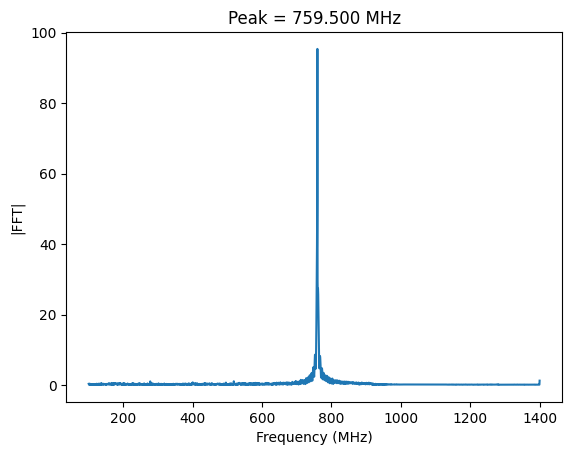

Demodulation frequency = 759.5 MHz


In [2]:
# import matplotlib.pyplot as plt

# def find_demod_freq(X_train, fs, fmin=1e6, fmax=1.5e9, plot=True):
#     """
#     X_train: (B, T) real
#     fs: sampling rate (Hz)
#     fmin,fmax: search band
#     return: f_peak (Hz)
#     """
#     X = np.asarray(X_train, dtype=np.float64)

#     x_mean = X.mean(axis=0)
#     x_mean = x_mean - x_mean.mean()   # 去DC

#     F = np.fft.rfft(x_mean)
#     freq = np.fft.rfftfreq(len(x_mean), d=1/fs)
#     amp = np.abs(F)

#     mask = (freq >= fmin) & (freq <= fmax)
#     f_peak = freq[mask][np.argmax(amp[mask])]

#     if plot:
#         plt.figure()
#         plt.plot(freq[mask]/1e6, amp[mask])
#         plt.xlabel("Frequency (MHz)")
#         plt.ylabel("|FFT|")
#         plt.title(f"Peak = {f_peak/1e6:.3f} MHz")
#         plt.show()

#     return f_peak

fs = 2.8e9
f_demod = find_demod_freq(x, fs, fmin=100e6, fmax=1.5e9)
print("Demodulation frequency =", f_demod/1e6, "MHz")

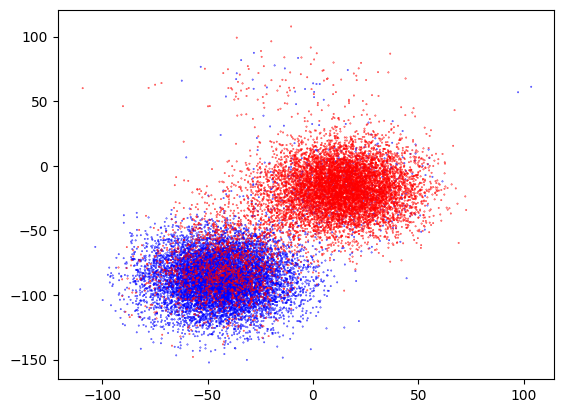

In [19]:
# f_demod = 759.5e6
# fs = 2.8e9
T = 4800
wave_time = np.arange(T) / fs
burn_out = 1000
I = np.dot(x[:,burn_out:-1], np.cos(2*np.pi*f_demod*wave_time[burn_out:-1]))
Q = np.dot(x[:,burn_out:-1], np.sin(2*np.pi*f_demod*wave_time[burn_out:-1]))

plt.scatter(I, Q, s=0.1, c=y, cmap="bwr")

# 简单分类

对 IQ 信号进行简单平均，$I=\langle I(t)\rangle$, $Q=\langle Q(t)\rangle$，再用逻辑回归或支持向量机直接进行分类。

In [23]:
import numpy as np

def demod_iq(x, f_demod, fs, phase=0.0):
    # x: (B,T) real
    t = np.arange(x.shape[1]) / fs
    I = x * np.cos(2*np.pi*f_demod*t + phase)
    Q = x * np.sin(2*np.pi*f_demod*t + phase)
    return np.stack([I, Q], axis=-1)  # (B,T,2)

def split_9to1(x, y, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    rng.shuffle(idx)
    n_train = int(0.9 * len(y))
    tr, te = idx[:n_train], idx[n_train:]
    return x[tr], y[tr], x[te], y[te]

# 用法
# x.shape=(B,T), y.shape=(B,)
X = demod_iq(x, f_demod=f_demod, fs=fs, phase=0.0)  # (B,T,2)
X_train, y_train, X_test, y_test = split_9to1(X, y, seed=123)

In [29]:
f

{'0': ['S21Q1_20260126104404.qdat',
  'S21Q1_20260126104526.qdat',
  'S21Q1_20260126104534.qdat',
  'S21Q1_20260126104543.qdat',
  'S21Q1_20260126104600.qdat'],
 '1': ['S21Q1_20260126104835.qdat',
  'S21Q1_20260126104844.qdat',
  'S21Q1_20260126104853.qdat',
  'S21Q1_20260126104901.qdat',
  'S21Q1_20260126104911.qdat']}

In [30]:
import json
np.savez_compressed(
    os.path.join(dir, "IQ_featured_data"),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    meta=f,
)

In [ ]:
import numpy as np
import torch
from src.common import make_loader
from src.readout import train_simple, eval_nn
from src.readout import LDA, MatchedFilter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 10

# d = np.load("data/test_readout.npz", allow_pickle=True)
d = np.load("data/readout_data/IQ_featured_data.npz", allow_pickle=True)
X_train, y_train, X_test, y_test = d["X_train"], d["y_train"], d["X_test"], d["y_test"]

# Prepare loaders for ML
train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)
test_loader  = make_loader(X_test, y_test, batch_size=2048, shuffle=False)
T = X_train.shape[1]

lda = train_simple(LDA(T), train_loader, device, epochs=epochs)[0]
acc_lda, nll_lda = eval_nn(lda, test_loader, device)

mf = train_simple(MatchedFilter(T), train_loader, device, epochs=epochs)[0]
acc_mf, nll_mf = eval_nn(mf, test_loader, device)



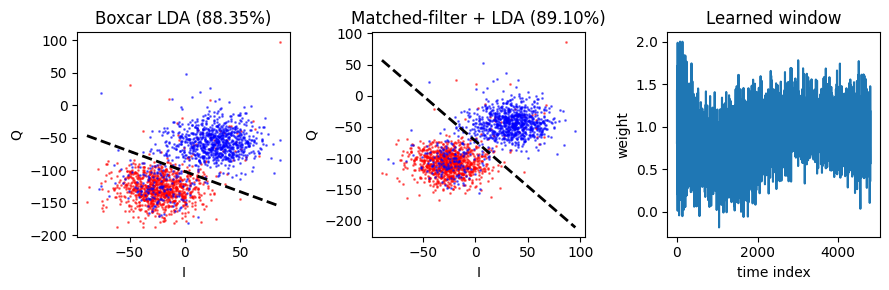

In [26]:
import matplotlib.pyplot as plt

I = X_test[:,:,0].sum(axis=1)
Q = X_test[:,:,1].sum(axis=1)

w = (lda.fc.weight[1] - lda.fc.weight[0]).detach().cpu().numpy()
c = (lda.fc.bias[1]   - lda.fc.bias[0]).detach().cpu().item()

plt.figure(figsize=(9,3))
# ---------- (1) boxcar IQ + LDA 直线 ----------
plt.subplot(1,3,1)
plt.scatter(I[y_test==0], Q[y_test==0], s=1, alpha=0.5, c='r')
plt.scatter(I[y_test==1], Q[y_test==1], s=1, alpha=0.5, c='b')

I_line = np.linspace(np.min(I), np.max(I), 200)
if abs(w[1]) < 1e-12:
    plt.axvline(-c/(w[0]+1e-12), linestyle="--")
else:
    Q_line = -(w[0]*I_line + c)/w[1]
    plt.plot(I_line, Q_line, "k--", linewidth=2)

plt.title(f"Boxcar LDA ({acc_lda*100:{".2f"}}%)")
plt.xlabel("I"); plt.ylabel("Q"); 

w_t = mf.window.detach().cpu().numpy().flatten()
I2 = (X_test[:,:,0]*w_t).sum(axis=1)
Q2 = (X_test[:,:,1]*w_t).sum(axis=1)

w2 = (mf.fc.weight[1] - mf.fc.weight[0]).detach().cpu().numpy()
c2 = (mf.fc.bias[1]   - mf.fc.bias[0]  ).detach().cpu().item()

# ---------- (2) matched-filter IQ + MF 直线 ----------
plt.subplot(1,3,2)
plt.scatter(I2[y_test==0], Q2[y_test==0], s=1, alpha=0.5, c='r')
plt.scatter(I2[y_test==1], Q2[y_test==1], s=1, alpha=0.5, c='b')

I_line2 = np.linspace(np.min(I2), np.max(I2), 200)
if abs(w2[1]) < 1e-12:
    plt.axvline(-c2/(w2[0]+1e-12), linestyle="--")
else:
    Q_line2 = -(w2[0]*I_line2 + c2)/w2[1]
    plt.plot(I_line2, Q_line2, "k--", linewidth=2)

plt.title(f"Matched-filter + LDA ({100*acc_mf:{".2f"}}%)")
plt.xlabel("I"); plt.ylabel("Q"); 

# ---------- (3) matched filter window ----------
plt.subplot(1,3,3)
plt.plot(w_t)
plt.title("Learned window")
plt.xlabel("time index"); plt.ylabel("weight")
plt.tight_layout()
plt.show()

# 用各种机器学习模型分类

优势在于充分利用了 $I(t)$，$Q(t)$ 中的时间信息。

1. 训练时间窗，通过数字滤波（Matched filter）得到 IQ 点
2. 训练两个状态对应的模板，用贝叶斯推断
3. 训练神经网络

In [31]:
import subprocess
import json
import matplotlib.pyplot as plt
import pandas as pd 

# Run the script and capture output
# data_file = 'data/test_readout.npz'
data_file = "data/readout_data/IQ_featured_data.npz"
result = subprocess.run(
    ['python', '-m', 'scripts.run_readout_all', '--in_npz', data_file, 
     '--em_iter', '100', '--hmm_iter', '100', '--epochs=100'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
)

if result.stderr == '':
    # Capture the results dictionary from the stdout (if printed by the script)
    json_output = result.stdout.split("All Results:")[-1].strip().replace("'", '"')
    results = json.loads(json_output)

    # Extract accuracies for plotting
    methods =list(results.keys())
    accuracies = [results[method]["acc"] for method in methods]
    nlls = [results[method]["nll"] for method in methods]

    # Plot the accuracies as a bar chart
    fig, ax = plt.subplots()
    bars = plt.barh(methods[::-1], accuracies[::-1], color="b")
    ax.bar_label(bars)
    ax.set_xlim((0.9, 1.0))
    ax.set_xlabel('Accuracy')
    ax.set_title('Accuracy of Each Method')
    # plt.grid(True, axis='x')
    plt.show()
    
    display( pd.DataFrame(results).transpose() )
else:
    print( result.stderr )


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\GitHub\qpu-gpu-co-processing\scripts\run_readout_all.py", line 124, in <module>
    results = main()
  File "d:\GitHub\qpu-gpu-co-processing\scripts\run_readout_all.py", line 78, in main
    trm, his = train_simple(TinyTransformer(T), train_loader, device, epochs=args.epochs)
               ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\GitHub\qpu-gpu-co-processing\src\readout\train_readout.py", line 59, in train_simple
    out = model(X)
  File "c:\Users\Zhou\anaconda3\envs\qai\Lib\site-packages\torch\nn\modules\module.py", line 1775, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\Zhou\anaconda3\envs\qai\Lib\site-packages\torch\nn\modules\module.py", line 1786, in _call_impl
    return forward_call(*args, **kwargs)
  Fi

In [34]:
print(result.stdout)

device: cuda
[A] Linear Classifier: acc=0.8585  NLL=0.4080, TIME=19.2024
[B] Matched Filter + LDA: acc=0.8760  NLL=0.3727, TIME=19.4498
[C] Bayes-only: acc=0.8970  NLL=1.9485
[D] Bayes-EM (weak anchor): acc=0.8955  NLL=2.0806  sigma=0.250
[E] CNN: acc=0.8825  NLL=0.3590, TIME=195.0012

